## 1. Análisis Exploratorio de Datos (EDA)

### 1.1 Carga de los datos


Para este miniproyecto contamos con un dataset de `Kaggle`, el cual viene comprimido en un archivo .gz, por lo que, para ahorrar espacio en el disco, decidimos descomprimir este archivo directamente en este notebook.

In [1]:
# ============================================
# CARGA DE DATOS - VERSIÓN SIMPLE Y CORRECTA
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

ruta_train = r"C:\DL\miniproyecto_1\data\train.gz"

print(f"Inicio carga: {datetime.now().strftime('%H:%M:%S')}")
df = pd.read_csv(ruta_train, compression='gzip')
print(f"✅ Cargados {len(df):,} registros")
print(f"Fin carga: {datetime.now().strftime('%H:%M:%S')}")
print(f"\nColumnas: {df.columns.tolist()}")

pd.set_option('display.max_columns', None) #Para mostrar todas las columnas del head()
df.head()

Inicio carga: 19:15:04
✅ Cargados 40,428,967 registros
Fin carga: 19:17:01

Columnas: ['id', 'click', 'hour', 'C1', 'banner_pos', 'site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21']


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.000009e+18,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,ddd2926e,44956a24,1,2,15706,320,50,1722,0,35,-1,79
1,1.000017e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,96809ac8,711ee120,1,0,15704,320,50,1722,0,35,100084,79
2,1.000037e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b3cf8def,8a4875bd,1,0,15704,320,50,1722,0,35,100084,79
3,1.000064e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,e8275b8f,6332421a,1,0,15706,320,50,1722,0,35,100084,79
4,1.000068e+19,0,14102100,1005,1,fe8cc448,9166c161,0569f928,ecad2386,7801e8d9,07d7df22,a99f214a,9644d0bf,779d90c2,1,0,18993,320,50,2161,0,35,-1,157


### 1.2 Análisis de la distribución de la variable `click` (objetivo)

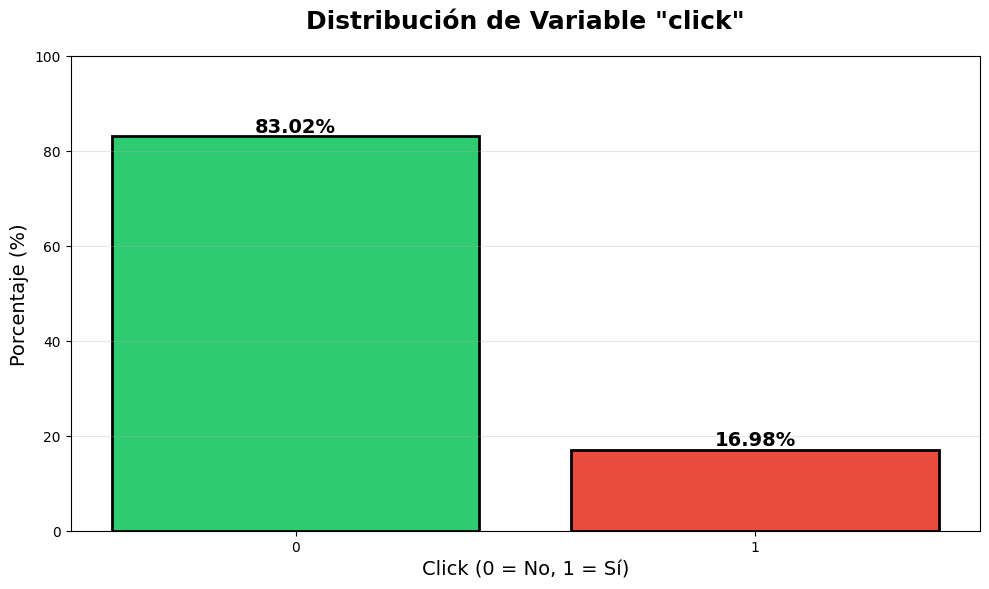


Estadísticas:
  - Total de observaciones: 40,428,967
  - No click (0): 83.02% (33,563,901)
  - Click (1): 16.98% (6,865,066)


In [28]:
# ANÁLISIS DE VARIABLE OBJETIVO
click_dist = df['click'].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 6))
bars = plt.bar(click_dist.index.astype(str), click_dist.values, 
               color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=2)
plt.title('Distribución de Variable "click"', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Click (0 = No, 1 = Sí)', fontsize=14)
plt.ylabel('Porcentaje (%)', fontsize=14)

# Añadir etiquetas
for bar, val in zip(bars, click_dist.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.2f}%', ha='center', fontsize=14, fontweight='bold')

plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nEstadísticas:")
print(f"  - Total de observaciones: {len(df):,}")
print(f"  - No click (0): {click_dist[0]:.2f}% ({int(click_dist[0]*len(df)/100):,})")
print(f"  - Click (1): {click_dist[1]:.2f}% ({int(click_dist[1]*len(df)/100):,})")


Gracias a este diagrama podemos observar un claro desbalance en la distribución de la variable `click`, siendo la clase 0 (no click) la clase mayoritaria y la clase 1 (click) la minoritaria.

Veamos ahora los tipos de variables con los que contamos y si contamos o no con valores faltantes en ellas.

### 1.3 Verificación de valores faltantes y tipos de datos

In [ ]:
# INFORMACIÓN DEL DATAFRAME
print("Información del DataFrame:")
print(df.info())

print("\nValores nulos:")
null_counts = df.isnull().sum()
null_cols = null_counts[null_counts > 0]
if len(null_cols) > 0:
    print("Columnas con valores nulos:")
    for col, val in null_cols.items():
        print(f"  - {col}: {val:,} nulos ({val/len(df)*100:.2f}%)")
else:
    print("No hay valores nulos")

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40428967 entries, 0 to 40428966
Data columns (total 24 columns):
 #   Column            Dtype  
---  ------            -----  
 0   id                float64
 1   click             int64  
 2   hour              int64  
 3   C1                int64  
 4   banner_pos        int64  
 5   site_id           object 
 6   site_domain       object 
 7   site_category     object 
 8   app_id            object 
 9   app_domain        object 
 10  app_category      object 
 11  device_id         object 
 12  device_ip         object 
 13  device_model      object 
 14  device_type       int64  
 15  device_conn_type  int64  
 16  C14               int64  
 17  C15               int64  
 18  C16               int64  
 19  C17               int64  
 20  C18               int64  
 21  C19               int64  
 22  C20               int64  
 23  C21               int64  
dtypes: float64(1), int64(14), object(9)
memory usag

Usando `.info()` podemos ver los tipos de las variables, donde hay 14 variables numéricas (`int64`) y 9 categóricas (`object`), sin embargo sabemos que las variables `C1`, `C14`,`C15`,`C16`,`C17`,`C18`,`C19`,`C20` y `C21` son en realidad variables categóricas, por lo que deberemos tener en cuenta esto al momento de utilizarlas.

Antes de continuar con el análisis, verifiquemos que no hayan registros duplicados en el dataset.

In [2]:
df.drop_duplicates(inplace=True)
print(f"\nRegistros después de eliminar duplicados: {len(df):,}")


Registros después de eliminar duplicados: 40,428,967


Dado que el número de registros resultantes es el mismo que el original, no hay duplicados en el dataset.

### 1.4 Análisis de la cardinalidad de las variables categóricas

A continuación presentamos la cardinalidad de las variables teniendo en cuenta también aquellas que están registradas como números.

ANÁLISIS DE CARDINALIDAD
\Variables categóricas de texto (9):
  - site_id: 4,737 valores únicos
  - site_domain: 7,745 valores únicos
  - site_category: 26 valores únicos
  - app_id: 8,552 valores únicos
  - app_domain: 559 valores únicos
  - app_category: 36 valores únicos
  - device_id: 2,686,408 valores únicos
  - device_ip: 6,729,486 valores únicos
  - device_model: 8,251 valores únicos

Variables numérico-categóricas:
  - C1: 7 valores únicos
  - banner_pos: 7 valores únicos
  - device_type: 5 valores únicos
  - device_conn_type: 4 valores únicos
  - C14: 2,626 valores únicos
  - C15: 8 valores únicos
  - C16: 9 valores únicos
  - C17: 435 valores únicos
  - C18: 4 valores únicos
  - C19: 68 valores únicos
  - C20: 172 valores únicos
  - C21: 60 valores únicos


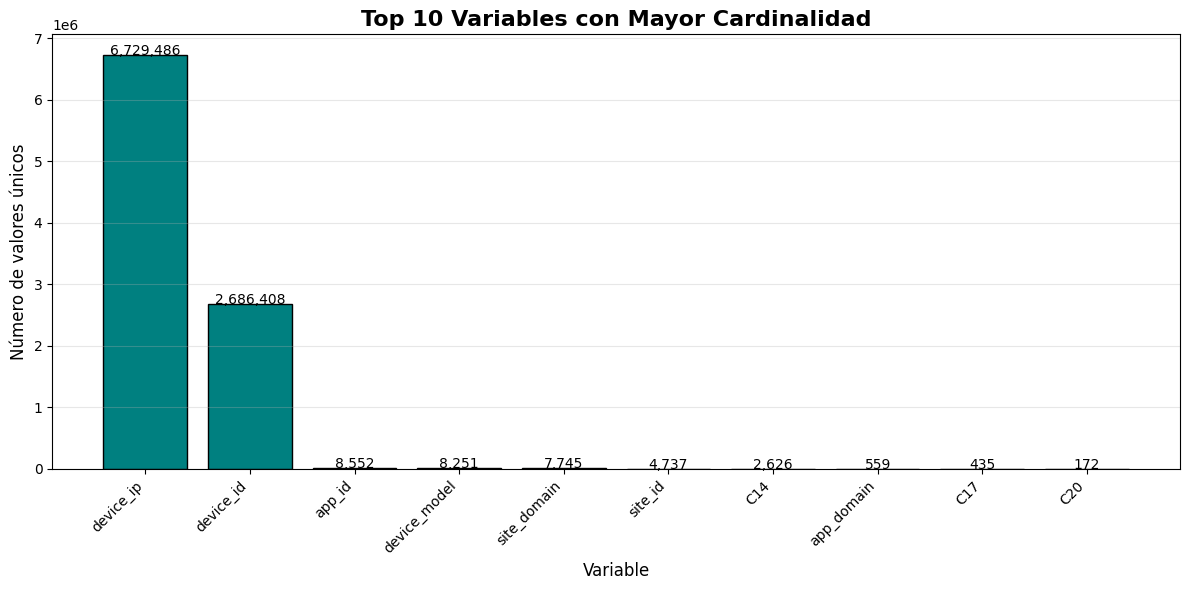

In [ ]:
print("ANÁLISIS DE CARDINALIDAD")

# Variables categóricas de texto
cat_texto = df.select_dtypes(include=['object']).columns.tolist()
print(f"\Variables categóricas de texto ({len(cat_texto)}):")
cardinalidad = {}
for col in cat_texto:
    n_unique = df[col].nunique()
    cardinalidad[col] = n_unique
    print(f"  - {col}: {n_unique:,} valores únicos")

# Variables numérico-categóricas
num_cat = ['C1', 'banner_pos', 'device_type', 'device_conn_type', 
           'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21']
print(f"\nVariables numérico-categóricas:")
for col in num_cat:
    if col in df.columns:
        n_unique = df[col].nunique()
        cardinalidad[col] = n_unique
        print(f"  - {col}: {n_unique:,} valores únicos")

# Visualizar top 10 de cardinalidad
top_cardinalidad = pd.Series(cardinalidad).sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(top_cardinalidad)), top_cardinalidad.values, color='teal', edgecolor='black')
plt.xticks(range(len(top_cardinalidad)), top_cardinalidad.index, rotation=45, ha='right')
plt.title('Top 10 Variables con Mayor Cardinalidad', fontsize=16, fontweight='bold')
plt.xlabel('Variable', fontsize=12)
plt.ylabel('Número de valores únicos', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Añadir valores
for bar, val in zip(bars, top_cardinalidad.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{val:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Las variables `devide_ip` y `device_id` cuentan demasiadas categorías (6.7M y 2.7M). En un proyecto real, se usaría hashing o embedding, pero para este proyecto las excluimos.



Utilizando ahora el estádistico V de Cramér revisemos la correlación entre las variables categóricas.

Calculando V de Cramér... (puede tardar unos segundos)


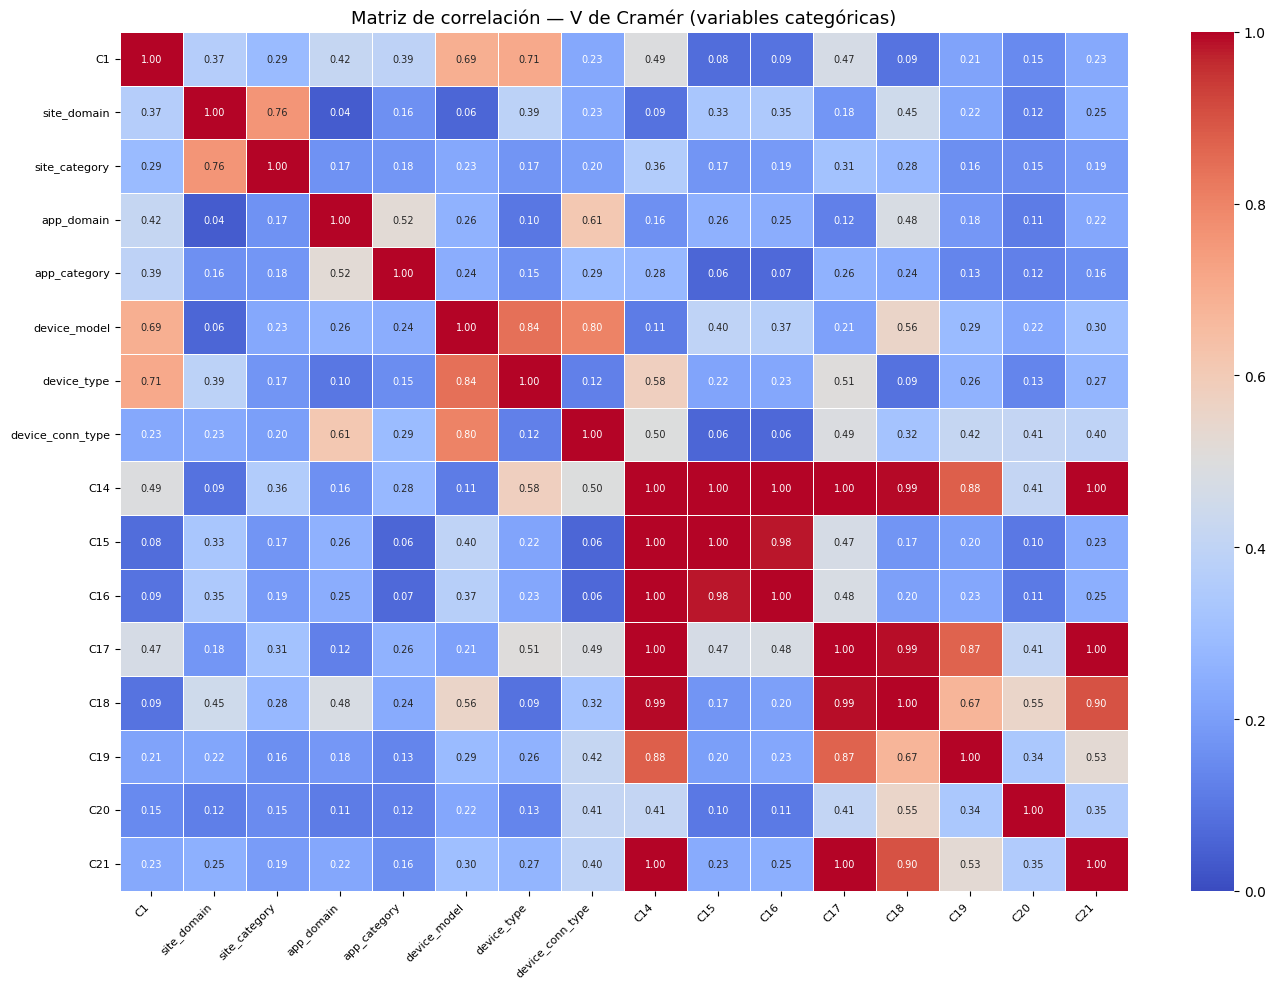


Pares con alta correlación (V de Cramér > 0.7):
  C1 ↔ device_type: 0.707
  site_domain ↔ site_category: 0.762
  device_model ↔ device_type: 0.843
  device_model ↔ device_conn_type: 0.805
  C14 ↔ C15: 1.000
  C14 ↔ C16: 1.000
  C14 ↔ C17: 1.000
  C14 ↔ C18: 0.993
  C14 ↔ C19: 0.879
  C14 ↔ C21: 1.000
  C15 ↔ C16: 0.983
  C17 ↔ C18: 0.992
  C17 ↔ C19: 0.868
  C17 ↔ C21: 1.000
  C18 ↔ C21: 0.902


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calcula V de Cramér entre dos columnas categóricas."""
    tabla = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(tabla)
    n = tabla.sum().sum()
    r, k = tabla.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# Columnas categóricas
categorical_features = [
    'C1', 'site_domain', 'site_category',
    'app_domain', 'app_category', 'device_model',
    'device_type', 'device_conn_type',
    'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21'
]

# Calcular matriz de V de Cramér

cols = [c for c in categorical_features if c in df.columns]

print("Calculando V de Cramér... (puede tardar unos segundos)")
matriz = pd.DataFrame(index=cols, columns=cols, dtype=float)

for col1 in cols:
    for col2 in cols:
        if col1 == col2:
            matriz.loc[col1, col2] = 1.0
        else:
            matriz.loc[col1, col2] = cramers_v(
                df[col1],
                df[col2]
            )

# Visualización
plt.figure(figsize=(14, 10))
sns.heatmap(
    matriz.astype(float),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=0, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 7}
)
plt.title("Matriz de correlación — V de Cramér (variables categóricas)", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("correlacion_categoricas.png", dpi=150, bbox_inches="tight")
plt.show()

# Pares con alta correlación (> 0.7)
print("\nPares con alta correlación (V de Cramér > 0.7):")
for i, col1 in enumerate(cols):
    for col2 in cols[i+1:]:
        val = matriz.loc[col1, col2]
        if val > 0.7:
            print(f"  {col1} ↔ {col2}: {val:.3f}")

Como podemos apreciar en la matriz de correlación y en la posterior salida, existen correlaciones altas, e incluso perfectas, entre algunas de las variables categóricas consideradas, esto lo consideraremos a la hora de seleccionar las variables, también tendremos en cuenta su cardinalidad.

In [2]:
# ============================================
# SELECCIÓN DE VARIABLES BASADA EN CARDINALIDAD
# ============================================
print("=" * 60)
print("SELECCIÓN DE VARIABLES BASADA EN CARDINALIDAD")
print("=" * 60)

# Verificar que df existe y tiene datos
if 'df' not in locals():
    print("ERROR: df no está definido. Ejecuta primero la celda de carga.")
else:
    print(f"DataFrame cargado: {df.shape}")
    
    # Variables con cardinalidad EXTREMA (descartamos)
    vars_excluir = ['device_ip', 'device_id', 'device_model', 
                    'site_id', 'app_id']
    
    print(f"\nVariables EXCLUIDAS (cardinalidad extrema):")
    vars_excluir_existentes = [v for v in vars_excluir if v in df.columns]
    for v in vars_excluir_existentes:
        print(f"  - {v}: {df[v].nunique():,} valores únicos")
    
    # Variables categóricas con cardinalidad BAJA
    vars_onehot = ['site_category', 'app_category', 
                   'C1', 'banner_pos', 'device_type', 'device_conn_type',
                   'C15', 'C16', 'C18']
    
    print(f"\nVariables para OneHotEncoder (cardinalidad baja):")
    vars_onehot_existentes = [v for v in vars_onehot if v in df.columns]
    for v in vars_onehot_existentes:
        print(f"  - {v}: {df[v].nunique()} valores únicos")
    
    
    # Variables de alta cardinalidad (Target Encoding)
    vars_target = ['C14', 'C17', 'C19', 'C20', 'C21', 'app_domain', 'site_domain']
    
    print(f"\nVariables para Target Encoding (cardinalidad media/alta):")
    vars_target_existentes = [v for v in vars_target if v in df.columns]
    for v in vars_target_existentes:
        print(f"  - {v}: {df[v].nunique()} valores únicos")
    
    # Variable objetivo
    target = 'click'
    
    # Variables seleccionadas (simplificado)
    cols_seleccionadas = [
        'click',
        'site_category', 'site_domain', 
        'app_category', 'app_domain',
        'C1', 'banner_pos', 'device_type', 'device_conn_type',
        'C16',  'C18', 'C19',
        'C20'  
    ]
    
    # Verificar que todas las columnas existen
    cols_seleccionadas = [col for col in cols_seleccionadas if col in df.columns]
    
    print(f"\nTotal variables seleccionadas: {len(cols_seleccionadas)}")
    print("Lista final:")
    for col in cols_seleccionadas:
        print(f"  - {col}")
    
    # Crear DataFrame reducido
    df_modelo = df[cols_seleccionadas].copy()
    
    print(f"\nDataFrame reducido creado: {df_modelo.shape}")

SELECCIÓN DE VARIABLES BASADA EN CARDINALIDAD
DataFrame cargado: (40428967, 24)

Variables EXCLUIDAS (cardinalidad extrema):
  - device_ip: 6,729,486 valores únicos
  - device_id: 2,686,408 valores únicos
  - device_model: 8,251 valores únicos
  - site_id: 4,737 valores únicos
  - app_id: 8,552 valores únicos

Variables para OneHotEncoder (cardinalidad baja):
  - site_category: 26 valores únicos
  - app_category: 36 valores únicos
  - C1: 7 valores únicos
  - banner_pos: 7 valores únicos
  - device_type: 5 valores únicos
  - device_conn_type: 4 valores únicos
  - C15: 8 valores únicos
  - C16: 9 valores únicos
  - C18: 4 valores únicos

Variables para Target Encoding (cardinalidad media/alta):
  - C14: 2626 valores únicos
  - C17: 435 valores únicos
  - C19: 68 valores únicos
  - C20: 172 valores únicos
  - C21: 60 valores únicos
  - app_domain: 559 valores únicos
  - site_domain: 7745 valores únicos

Total variables seleccionadas: 13
Lista final:
  - click
  - site_category
  - site_d

Decidimos descartar algunas variables `C14-C21` debido a sus altas correlaciones entre si mostradas en la matriz de correlación. Además, conservamos el dominio del sitio web y la app debido a que este puede tener una gran influencia a la hora de que un usuario de click en un anuncio.

In [3]:
df_modelo.head()

,click,site_category,site_domain,app_category,app_domain,C1,banner_pos,device_type,device_conn_type,C16,C18,C19,C20
0,0,28905ebd,f3845767,07d7df22,7801e8d9,1005,0,1,2,50,0,35,-1
1,0,28905ebd,f3845767,07d7df22,7801e8d9,1005,0,1,0,50,0,35,100084
2,0,28905ebd,f3845767,07d7df22,7801e8d9,1005,0,1,0,50,0,35,100084
3,0,28905ebd,f3845767,07d7df22,7801e8d9,1005,0,1,0,50,0,35,100084
4,0,0569f928,9166c161,07d7df22,7801e8d9,1005,1,1,0,50,0,35,-1


### 1.5 Transformación de la variable `hour`

A continuación transformamos la variable `hour` (la cual viene registrada en formato YYMMDDHH) en columnas separadas de año, mes, día y hora, junto con una franja horaria.

In [4]:
print("Transformando variable 'hour' (formato YYMMDDHH)")

def parse_hour(hour_val):
    """
    Extrae componentes de hora formato YYMMDDHH
    Ejemplo: 14091123 -> Año: 2014, Mes: 09, Día: 11, Hora: 23
    """
    hour_str = str(hour_val).zfill(8)  # Asegurar 8 dígitos
    
    year = 2000 + int(hour_str[0:2])    # YY -> 2000 + YY
    month = int(hour_str[2:4])           # MM
    day = int(hour_str[4:6])             # DD
    hour = int(hour_str[6:8])             # HH
    
    return year, month, day, hour

# Aplicar transformación
df['year'], df['month'], df['day'], df['hour_of_day'] = zip(*df['hour'].apply(parse_hour))

# Crear franja horaria (opcional, pero útil para análisis)
def get_time_slot(hour):
    if 5 <= hour < 12:
        return 'mañana'
    elif 12 <= hour < 18:
        return 'tarde'
    elif 18 <= hour < 23:
        return 'noche'
    else:
        return 'madrugada'

df['time_slot'] = df['hour_of_day'].apply(get_time_slot)

print("\nNuevas características creadas correctamente:")
print(f"  - hour_of_day: {df['hour_of_day'].min()}-{df['hour_of_day'].max()} (hora del día)")

print(f"  - time_slot: {df['time_slot'].unique().tolist()} (franjas horarias)")

# Mostrar ejemplos
print("\nEjemplos de transformación (primeras 10 filas):")
ejemplos = df[['hour', 'year', 'month', 'day', 'hour_of_day','time_slot']].head(10)
ejemplos

Transformando variable 'hour' (formato YYMMDDHH)

Nuevas características creadas correctamente:
  - hour_of_day: 0-23 (hora del día)
  - time_slot: ['madrugada', 'mañana', 'tarde', 'noche'] (franjas horarias)

Ejemplos de transformación (primeras 10 filas):


,hour,year,month,day,hour_of_day,time_slot
0,14102100,2014,10,21,0,madrugada
1,14102100,2014,10,21,0,madrugada
2,14102100,2014,10,21,0,madrugada
3,14102100,2014,10,21,0,madrugada
4,14102100,2014,10,21,0,madrugada
5,14102100,2014,10,21,0,madrugada
6,14102100,2014,10,21,0,madrugada
7,14102100,2014,10,21,0,madrugada
8,14102100,2014,10,21,0,madrugada
9,14102100,2014,10,21,0,madrugada


### 1.6 Histogramas de variables numéricas derivadas 

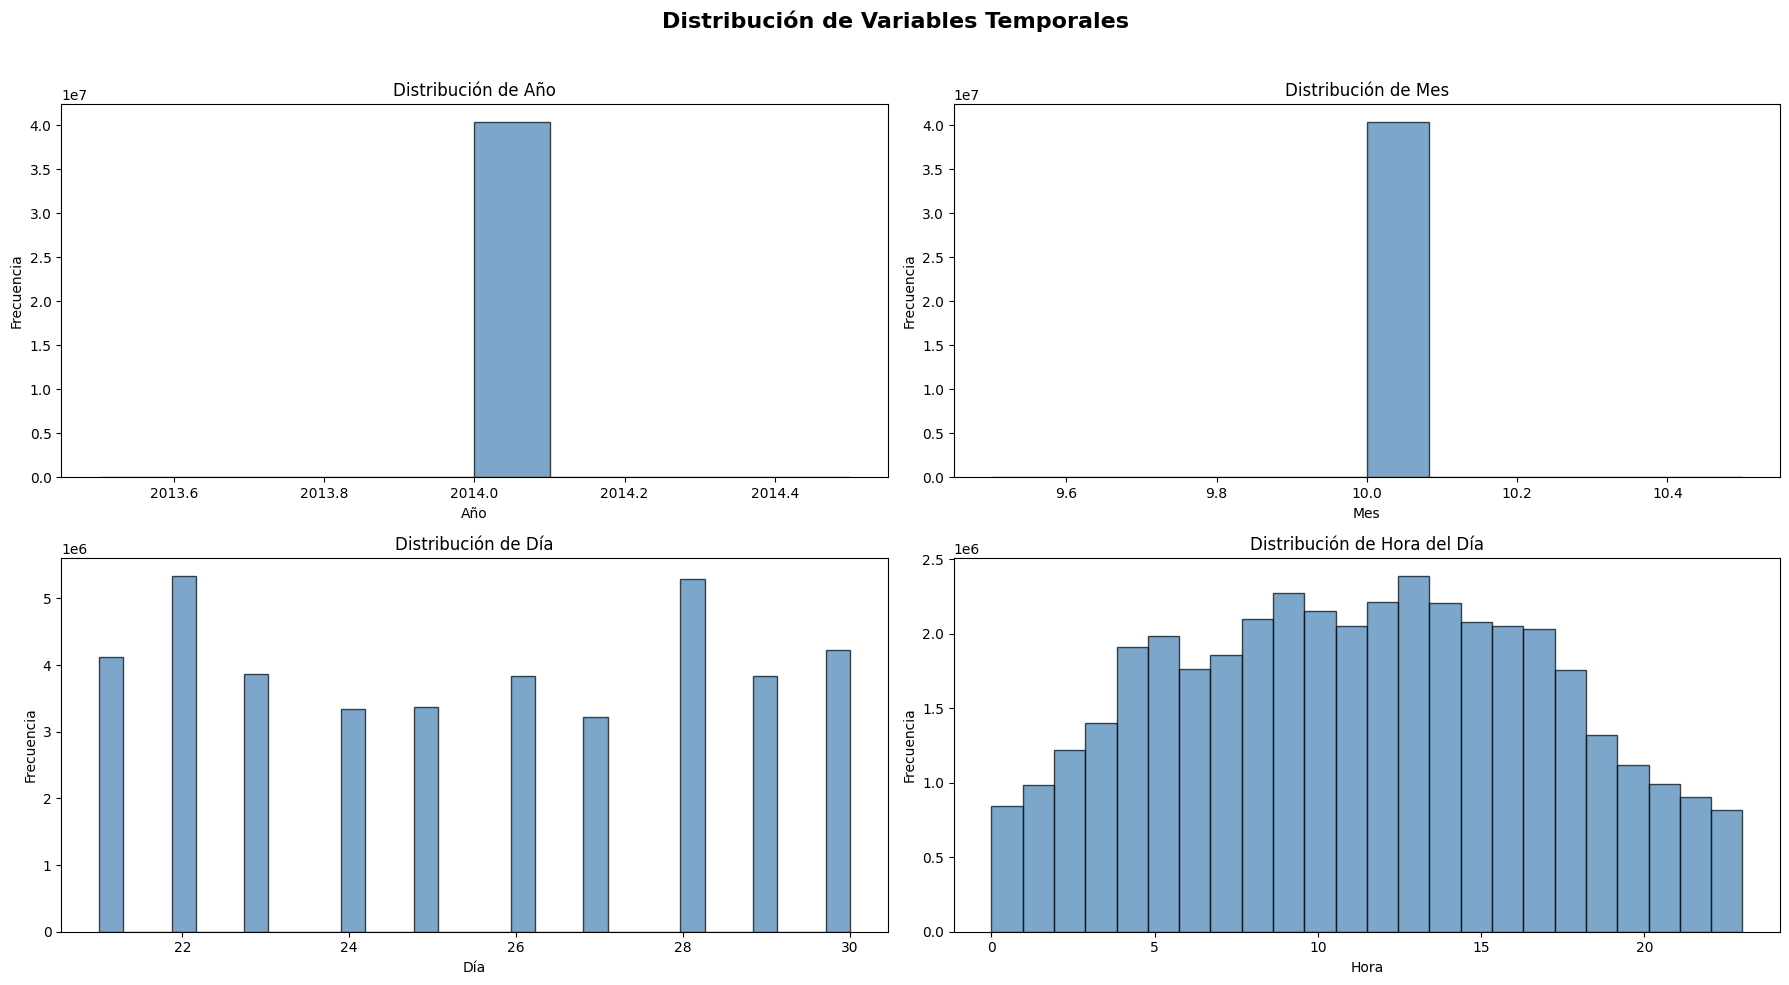

In [ ]:
# ============================================
# HISTOGRAMAS DE VARIABLES NUMÉRICAS DERIVADAS
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(18, 10))  # puedes ajustar el alto si quieres más espacio
fig.suptitle('Distribución de Variables Temporales', fontsize=16, fontweight='bold')

# year
axes[0, 0].hist(df['year'], bins=10, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('Distribución de Año')
axes[0, 0].set_xlabel('Año')
axes[0, 0].set_ylabel('Frecuencia')

# month
axes[0, 1].hist(df['month'], bins=12, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 1].set_title('Distribución de Mes')
axes[0, 1].set_xlabel('Mes')
axes[0, 1].set_ylabel('Frecuencia')

# day
axes[1, 0].hist(df['day'], bins=31, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 0].set_title('Distribución de Día')
axes[1, 0].set_xlabel('Día')
axes[1, 0].set_ylabel('Frecuencia')

# hour_of_day
axes[1, 1].hist(df['hour_of_day'], bins=24, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 1].set_title('Distribución de Hora del Día')
axes[1, 1].set_xlabel('Hora')
axes[1, 1].set_ylabel('Frecuencia')

plt.tight_layout(rect=[0, 0, 1, 0.96])  # deja espacio para el supertítulo
plt.show()

De estos histogramas podemos concluir que:

- Tal y como se anticipa en la descripción del dataset en `Kaggle`, dado que los datos disponibles solo son de 10 dias, se entiende que tanto el mes como el año tengan un único valor, ya que los datos van de 21 de octubre de 2014 al 30 de octubre de 2014.

- Se observa una tendencia, como es natural, a disminuir la actividad en horarios nocturnos y a aumentar en horarios diurnos.

- Los días con más tráfico en la web fueron el 22 de octubre y 28 de octubre.

Entonces, como una variable con un solo valor no es útil, eliminamos `year` y `month` del análisis, y además borramos la variable `hour` ya que esta ya se utilizó para crear las variables temporales.

In [19]:
df.drop(columns=['year', 'month','hour'], inplace=True)

### 1.7 Gráficos de frecuencia de las principales variables categóricas

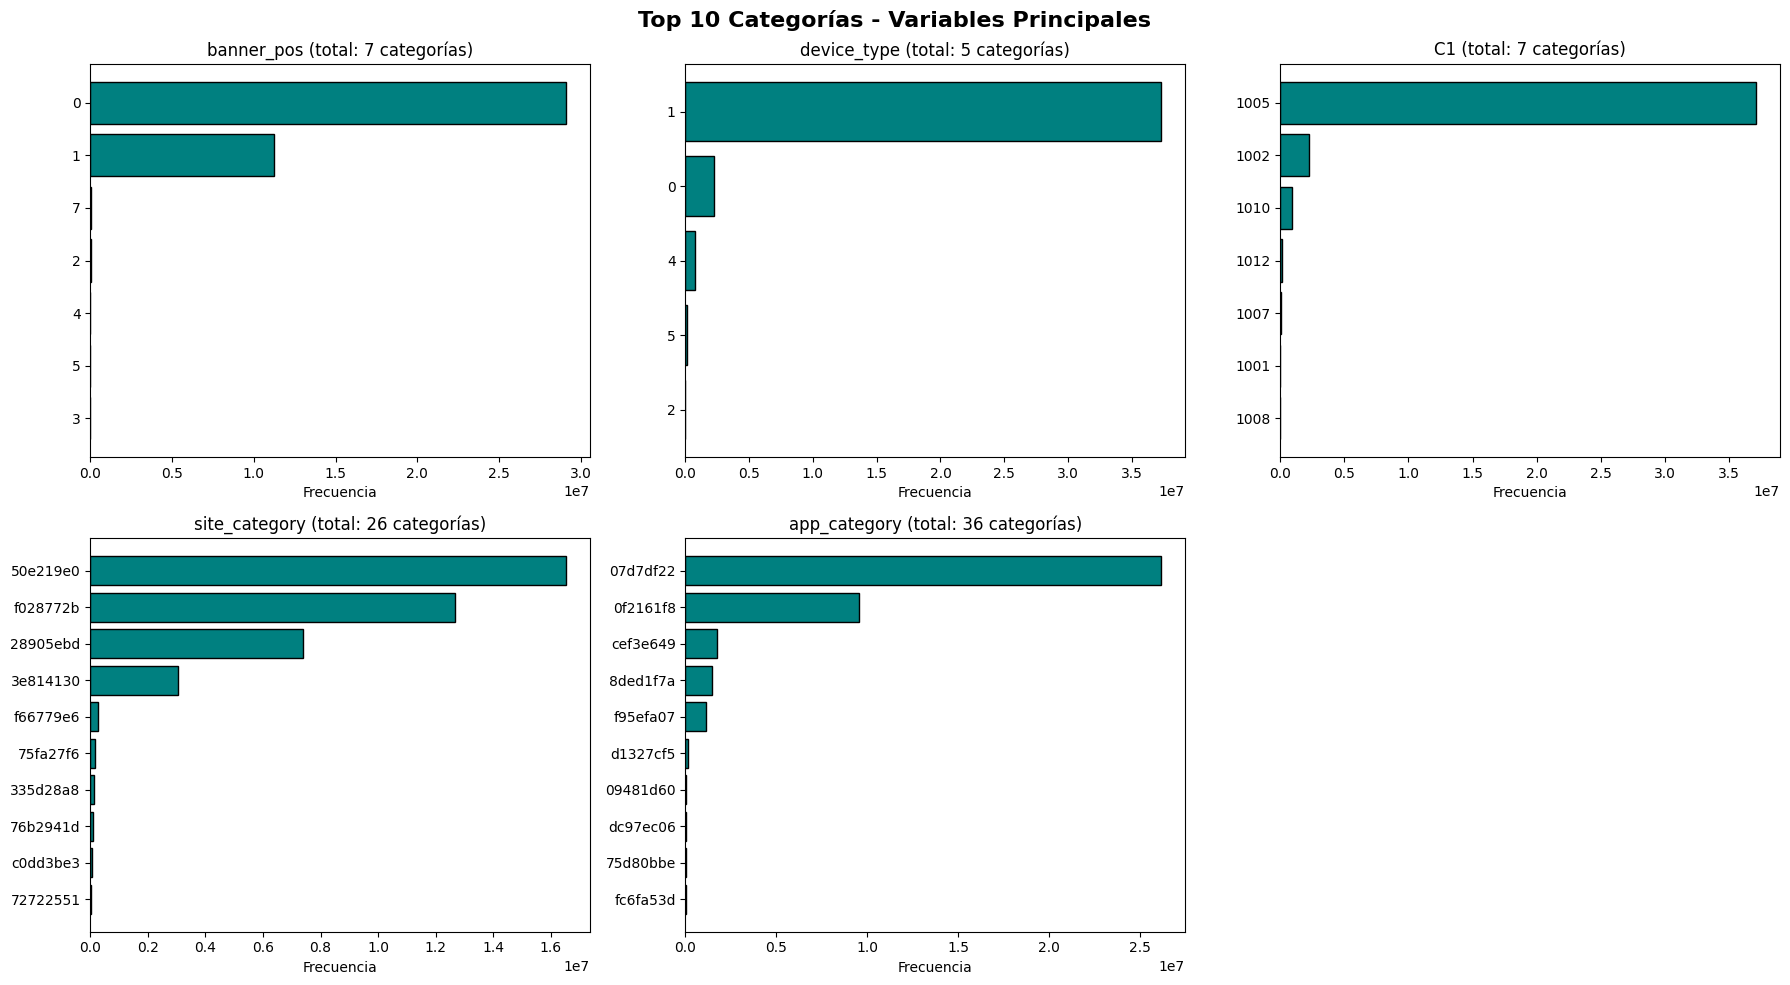

In [14]:
# ============================================
# FRECUENCIA DE VARIABLES CATEGÓRICAS PRINCIPALES
# ============================================
top_vars = ['banner_pos', 'device_type', 'C1', 'site_category', 'app_category']
top_vars = [v for v in top_vars if v in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Top 10 Categorías - Variables Principales', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(top_vars):
    top10 = df[col].value_counts().head(10)
    
    axes[i].barh(range(len(top10)), top10.values, color='teal', edgecolor='black')
    axes[i].set_yticks(range(len(top10)))
    axes[i].set_yticklabels(top10.index)
    axes[i].set_title(f'{col} (total: {df[col].nunique()} categorías)')
    axes[i].invert_yaxis()
    axes[i].set_xlabel('Frecuencia')

# Ocultar subplot vacío
for j in range(len(top_vars), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 1.8 Distribución de clicks por hora del día

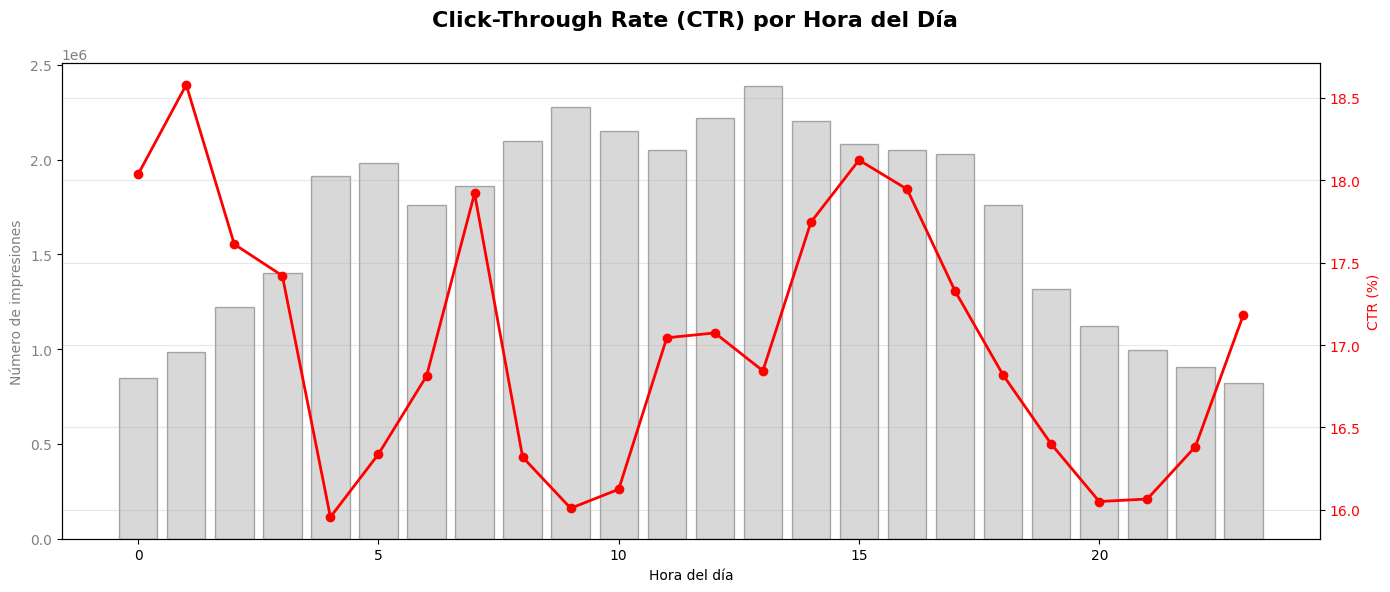

Hora con mayor CTR: 1:00 (18.58%)
Hora con menor CTR: 4:00 (15.96%)


In [15]:
# ============================================
# CTR POR HORA DEL DÍA
# ============================================
ctr_hour = df.groupby('hour_of_day')['click'].agg(['mean', 'count'])
ctr_hour.columns = ['ctr', 'impresiones']
ctr_hour['ctr'] *= 100

fig, ax1 = plt.subplots(figsize=(14, 6))
fig.suptitle('Click-Through Rate (CTR) por Hora del Día', fontsize=16, fontweight='bold')

# Barras de impresiones
color = 'gray'
ax1.bar(ctr_hour.index, ctr_hour['impresiones'], color=color, alpha=0.3, edgecolor='black')
ax1.set_xlabel('Hora del día')
ax1.set_ylabel('Número de impresiones', color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Línea de CTR
ax2 = ax1.twinx()
color = 'red'
ax2.plot(ctr_hour.index, ctr_hour['ctr'], color=color, marker='o', linewidth=2)
ax2.set_ylabel('CTR (%)', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Hora con mayor CTR: {ctr_hour['ctr'].idxmax()}:00 ({ctr_hour['ctr'].max():.2f}%)")
print(f"Hora con menor CTR: {ctr_hour['ctr'].idxmin()}:00 ({ctr_hour['ctr'].min():.2f}%)")

### 1.9 Matriz de correlación para variables numéricas creadas

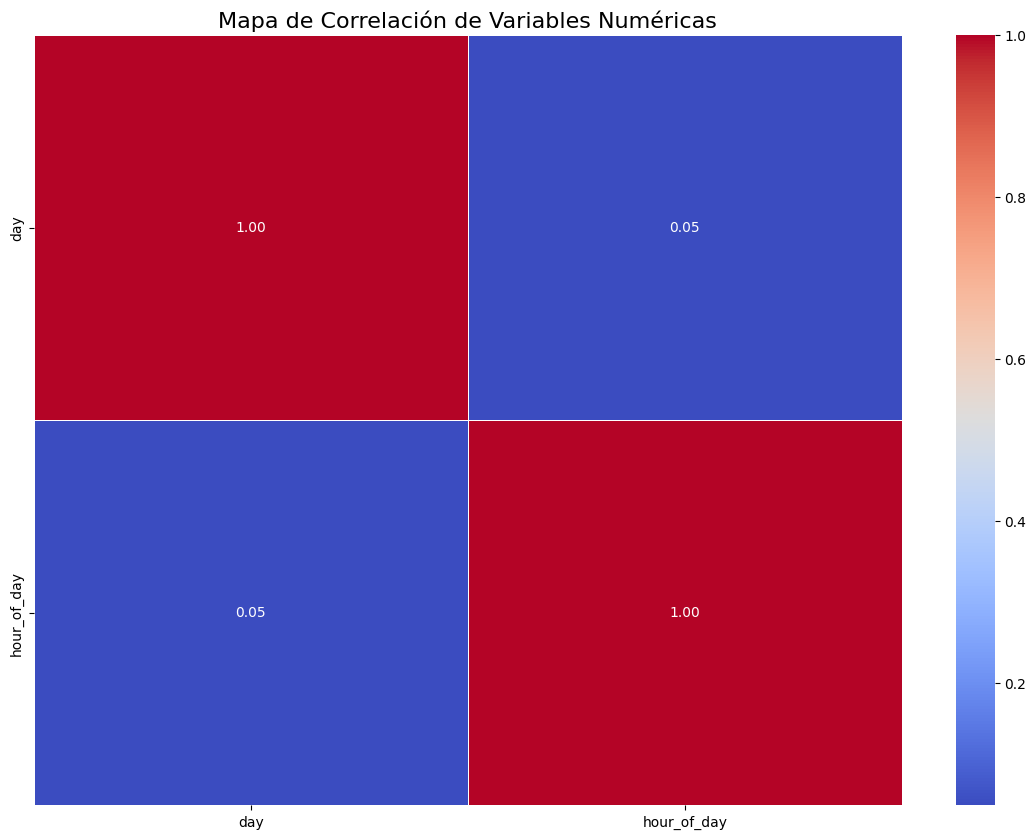

In [20]:
# ============================================
# MATRIZ DE CORRELACIÓN
# ============================================
# Variables numéricas a correlacionar
num_vars = ['day', 'hour_of_day']
correlation_matrix = df[num_vars].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Correlación de Variables Numéricas', size=16)
plt.show()

Finalmente, juntamos las variables temporales creadas con las variables seleccionadas que están en `df_modelo`.

In [21]:
df_modelo['day'] = df['day']
df_modelo['hour_of_day'] = df['hour_of_day']
df_modelo['time_slot'] = df['time_slot']

In [24]:
# ============================================
# SELECCIÓN FINAL DE VARIABLES - VERSIÓN SIMPLIFICADA
# ============================================
print("=" * 60)
print("SELECCIÓN FINAL DE VARIABLES - VERSIÓN SIMPLIFICADA")
print("=" * 60)

print(f"\n DataFrame final creado: {df_modelo.shape}")

print("\n Primeras 5 filas:")
df_modelo.head()



SELECCIÓN FINAL DE VARIABLES - VERSIÓN SIMPLIFICADA

 DataFrame final creado: (40428967, 16)

 Primeras 5 filas:


,click,site_category,site_domain,app_category,app_domain,C1,banner_pos,device_type,device_conn_type,C16,C18,C19,C20,day,hour_of_day,time_slot
0,0,28905ebd,f3845767,07d7df22,7801e8d9,1005,0,1,2,50,0,35,-1,21,0,madrugada
1,0,28905ebd,f3845767,07d7df22,7801e8d9,1005,0,1,0,50,0,35,100084,21,0,madrugada
2,0,28905ebd,f3845767,07d7df22,7801e8d9,1005,0,1,0,50,0,35,100084,21,0,madrugada
3,0,28905ebd,f3845767,07d7df22,7801e8d9,1005,0,1,0,50,0,35,100084,21,0,madrugada
4,0,0569f928,9166c161,07d7df22,7801e8d9,1005,1,1,0,50,0,35,-1,21,0,madrugada


In [32]:
ruta_final = r"C:\DL\miniproyecto_1\data\data_limpia.csv"
df_modelo.to_csv(ruta_final, index=False)
print(f"💾 Datos guardados en: {ruta_final}")

💾 Datos guardados en: C:\DL\miniproyecto_1\data\data_limpia.csv


### 1.10 Conclusiones

In [31]:
# ============================================
# CONCLUSIONES FINALES DEL EDA
# ============================================
print("=" * 60)
print("CONCLUSIONES DEL ANÁLISIS EXPLORATORIO")
print("=" * 60)

print("\n 1. VARIABLE OBJETIVO:")
print(f"   - Distribución: {click_dist[0]:.2f}% No Click, {click_dist[1]:.2f}% Click")

print("\n 2. CARDINALIDAD:")
print("   - Variables excluidas por alta cardinalidad:")
print("     • device_ip (313K), device_id (83K), device_model (4.5K)")
print("     • site_id (2K), app_id (2.3K), site_domain (2K)")
print("   - Variables para OneHotEncoder: site_category, app_category, banner_pos, etc.")

print("\n 3. PATRONES TEMPORALES:")
print("   - Los datos cubren múltiples horas y días ")

print("\n 4. VARIABLES SELECCIONADAS PARA MODELADO:")
print(f"   - Total: {len(df_modelo.columns)} columnas")
for col in df_modelo.columns:
    print(f"     • {col}")

print("\n 5. DATOS GUARDADOS:")
print(f"   - Ruta: {ruta_final}")
print(f"   - Dimensiones: {df_modelo.shape}")

print("\n 6. SIGUIENTE FASE: Fase 2 - Modelado con scikit-learn")

CONCLUSIONES DEL ANÁLISIS EXPLORATORIO

 1. VARIABLE OBJETIVO:
   - Distribución: 83.02% No Click, 16.98% Click

 2. CARDINALIDAD:
   - Variables excluidas por alta cardinalidad:
     • device_ip (313K), device_id (83K), device_model (4.5K)
     • site_id (2K), app_id (2.3K), site_domain (2K)
   - Variables para OneHotEncoder: site_category, app_category, banner_pos, etc.

 3. PATRONES TEMPORALES:
   - Los datos cubren múltiples horas y días 

 4. VARIABLES SELECCIONADAS PARA MODELADO:
   - Total: 16 columnas
     • click
     • site_category
     • site_domain
     • app_category
     • app_domain
     • C1
     • banner_pos
     • device_type
     • device_conn_type
     • C16
     • C18
     • C19
     • C20
     • day
     • hour_of_day
     • time_slot

 5. DATOS GUARDADOS:
   - Ruta: C:\Users\maria\OneDrive\Desktop\DEEP_LEARNING2\proyecto_ctr\datos\avazu_optimizado.csv
   - Dimensiones: (40428967, 16)

 6. SIGUIENTE FASE: Fase 2 - Modelado con scikit-learn
